# Phụ lục D: Tăng cường dữ liệu bằng phép co giãn ngẫu nhiên trên EfficientNet-B2

Trong thị giác máy tính thông thường (như phân loại ảnh đồ vật ImageNet), tăng cường dữ liệu (data augmentation) hầu như luôn là một thực hành tiêu chuẩn giúp mô hình học tính bất biến và nâng cao khả năng tổng quát hóa.

Tuy nhiên, trong bài toán phát hiện ảnh giả mạo (synthetic face forensics), các dấu vết phân biệt thường nằm ở mức tần số cao và tạo tác lưới điểm ảnh rất tinh vi. Một câu hỏi quan trọng được đặt ra:
- Liệu việc chủ động áp dụng phép co giãn ngẫu nhiên trong lúc huấn luyện có giúp mạng thích nghi tốt hơn với các sai lệch hình học, hay ngược lại, nó sẽ làm mờ và phá hỏng các tín hiệu phân biệt quan trọng?

Phụ lục này khảo sát câu hỏi trên thông qua một phép đối chứng có kiểm soát chặt chẽ:
- Kiến trúc thử nghiệm: EfficientNet-B2 (đầu vào 288x288 vùng tâm, trần 48 epoch, microbatch 8, batch hiệu dụng 24).
- Đối chứng trực tiếp: Mô hình `b2` chuẩn so với mô hình `b2_resize` (áp dụng phép co giãn ngẫu nhiên lúc train) trên toàn bộ 3-fold Out-Of-Fold (800 cặp phát triển).

Đây là phép thử cố định trên EfficientNet-B2 288px. Nó không thay `b2` bằng mô hình đơn động được chọn ở [Bài 05](05_backbone_and_selection.ipynb).


In [1]:
from pathlib import Path
import os
import sys

def find_task_root():
    explicit = os.environ.get('KMD_PROJECT_ROOT')
    if explicit:
        root = Path(explicit).expanduser().resolve()
        if (root / 'src/kmd').is_dir():
            return root
        raise FileNotFoundError('KMD_PROJECT_ROOT phải trỏ đến thư mục KeMaoDanh chứa src/kmd.')
    cwd = Path.cwd().resolve()
    for cand in [cwd, *cwd.parents]:
        if (cand / 'src/kmd').is_dir() and (cand / 'configs').is_dir():
            return cand.resolve()
        if (cand / 'KeMaoDanh/src/kmd').is_dir() and (cand / 'KeMaoDanh/configs').is_dir():
            return (cand / 'KeMaoDanh').resolve()
    raise FileNotFoundError("Không tìm thấy thư mục gốc KeMaoDanh chứa 'src/kmd' và 'configs'.")

TASK_ROOT = find_task_root()
if str(TASK_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(TASK_ROOT / 'src'))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.transforms import functional as TF

from kmd.core import PACKAGE, read_csv, split_fold, metric
from kmd.presets import get_preset_config
from kmd.pipeline import prepare_development, start_session, train_cnn_cv, aligned_predictions
from kmd.teaching import resolve_data_roots, show_pair_images

KMD_SMOKE = os.environ.get('KMD_SMOKE', '0') == '1'
KMD_RUN_ID = os.environ.get('KMD_RUN_ID', 'reasoning_pilot')
RUN_ID = f"{KMD_RUN_ID}_smoke" if (KMD_SMOKE and not KMD_RUN_ID.endswith('_smoke')) else KMD_RUN_ID

data_root, test_root = resolve_data_roots(TASK_ROOT)
if not data_root.is_dir() or not (data_root / 'pairs.csv').is_file():
    raise FileNotFoundError(
        f"Không tìm thấy thư mục dữ liệu huấn luyện tại '{data_root}'. "
        "Vui lòng thiết lập biến môi trường DATA_ROOT trỏ đến thư mục chứa 'pairs.csv' và 'images/'."
    )

dev_frame = prepare_development(data_root)
session_dir = start_session(dev_frame, data_root, run_id=RUN_ID)
print(f"Thư mục dự án: {TASK_ROOT}")
print(f"Phiên làm việc: {session_dir.relative_to(PACKAGE)}")
print(f"Tổng số mẫu phát triển: {len(dev_frame)} cặp")
print(f"Chế độ chạy thử (smoke test): {KMD_SMOKE}")

Thư mục dự án: /home/purin1410-desktop/kmd_full_v5_20260920/repo/KeMaoDanh
Phiên làm việc: artifacts/models/lesson_full_v5_20260920
Tổng số mẫu phát triển: 800 cặp
Chế độ chạy thử (smoke test): False


## 1. Cơ chế biến đổi: Phép co giãn ngẫu nhiên trong quá trình huấn luyện

Trong mã nguồn `kmd.data.Pairs`, cấu hình tăng cường `resize` được cài đặt như sau:
- **Điều kiện kích hoạt:** Chỉ áp dụng khi `training=True` và cấu hình có `augmentation='resize'`.
- **Xác suất xuất hiện:** Với xác suất 20% (`rng.random() < 0.2`) cho mỗi lần đọc ảnh.
- **Hệ số co dãn:** Một hệ số ngẫu nhiên được lấy mẫu từ phân bố đều trong đoạn từ 0.9 đến 1.0 (`factor = rng.uniform(0.9, 1.0)`).
- **Thao tác điểm ảnh:** Bức ảnh được co nhỏ về kích thước $[\text{round}(h \times factor), \text{round}(w \times factor)]$, sau đó phóng to ngược lại kích thước ban đầu $[h, w]$ bằng phép nội suy song tuyến tính có khử răng cưa (`antialias=True`).
- **Tập kiểm định được bảo vệ:** Tập kiểm định validation hoàn toàn không bao giờ bị áp dụng phép co giãn này; ảnh kiểm định luôn được xử lý theo quy chuẩn gốc.

Đoạn mã sau minh họa sự khác biệt trực quan giữa ảnh gốc và ảnh sau khi trải qua phép co giãn 0.9 rồi phóng to lại.

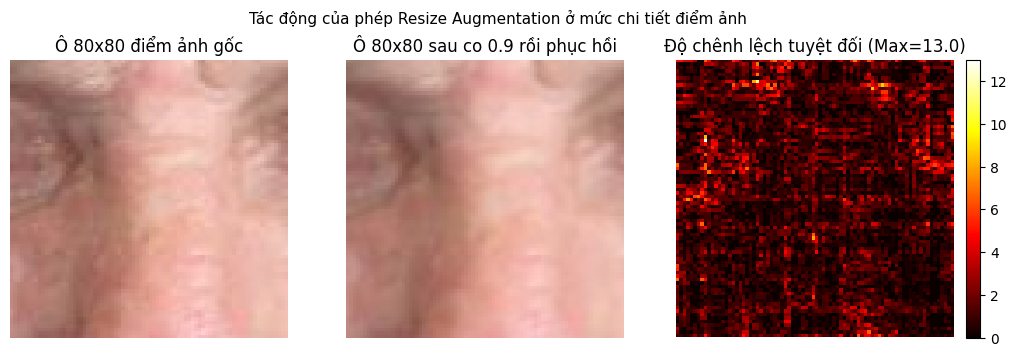

In [2]:
sample_row = dev_frame.sort_values('pair_id').iloc[0]
sample_img_path = data_root / sample_row.image_0

with Image.open(sample_img_path) as raw_im:
    im_rgb = raw_im.convert('RGB')
    w_orig, h_orig = im_rgb.size
    
    # Mô phỏng phép biến đổi b2_resize với factor 0.90
    factor_sim = 0.90
    h_down, w_down = round(h_orig * factor_sim), round(w_orig * factor_sim)
    im_down = TF.resize(im_rgb, [h_down, w_down], antialias=True)
    im_restored = TF.resize(im_down, [h_orig, w_orig], antialias=True)

# Trích xuất một ô nhỏ 80x80 ở vùng chi tiết khuôn mặt để so sánh
left, top = (w_orig - 80) // 2, (h_orig - 80) // 2
crop_box = (left, top, left + 80, top + 80)
patch_orig = im_rgb.crop(crop_box)
patch_restored = im_restored.crop(crop_box)

arr_orig = np.array(patch_orig, dtype=np.float32)
arr_restored = np.array(patch_restored, dtype=np.float32)
diff_abs = np.abs(arr_restored - arr_orig).mean(axis=-1)

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.5))
axes[0].imshow(patch_orig)
axes[0].set_title("Ô 80x80 điểm ảnh gốc")
axes[0].axis('off')

axes[1].imshow(patch_restored)
axes[1].set_title("Ô 80x80 sau co 0.9 rồi phục hồi")
axes[1].axis('off')

im_diff = axes[2].imshow(diff_abs, cmap='hot')
axes[2].set_title(f"Độ chênh lệch tuyệt đối (Max={diff_abs.max():.1f})")
axes[2].axis('off')
fig.colorbar(im_diff, ax=axes[2], fraction=0.046, pad=0.04)
fig.suptitle("Tác động của phép Resize Augmentation ở mức chi tiết điểm ảnh", fontsize=11)
plt.tight_layout()
plt.show()

## 2. Nguyên tắc phương pháp luận: Phân biệt hai khái niệm

Trước khi chạy mô hình, hai khái niệm phương pháp luận sau cần được phân định rạch ròi:

1. **Phân biệt Tăng cường dữ liệu (Augmentation) với Đối chứng nội suy (Resampling Control):**
   - Ở [Bài 04](04_native_and_resampling.ipynb) và [Phụ lục A](extension_a_representations.ipynb), việc so sánh `native` và `resampled` là nhằm trả lời câu hỏi: Khi toàn bộ dữ liệu đi qua một phép nội suy cố định, điểm của mô hình thay đổi theo hướng nào và bao nhiêu?
   - Ở đây, `b2_resize` là một kỹ thuật ngẫu nhiên hóa (stochastic regularization) được đưa vào pha huấn luyện để xem liệu mô hình có học được biểu diễn khái quát hơn hay không.

2. **Phân biệt Tính bền vững trước biến đổi (Robustness) và Điểm số trên tập kiểm định gốc:**
   - Mục tiêu của cuộc thi là đạt Macro-F1 cao nhất trên tập dữ liệu kiểm tra chuẩn của ban tổ chức, chứ không phải là kiểm tra khả năng chịu đựng ảnh bị bóp méo nhân tạo.
   - Không đưa ra kết luận hay số liệu về "stress test accuracy" nếu mã nguồn không thực sự thực hiện việc đánh giá trên tập ảnh bị gây nhiễu. Điểm số cần theo dõi duy nhất ở đây là Macro-F1 OOF trên 800 cặp phát triển sạch.

In [3]:
print("1. Đánh giá mô hình B2 chuẩn (EfficientNet-B2, 288px, trần 48 epoch) qua 3 fold...")
oof_b2 = train_cnn_cv('b2', dev_frame, data_root, session_dir, folds=(0, 1, 2), smoke=KMD_SMOKE)
sc_b2 = metric(dev_frame.fake_position, oof_b2.p)

print("\n2. Huấn luyện và đánh giá mô hình B2 + Resize Augmentation (b2_resize) qua 3 fold...")
oof_b2_resize = train_cnn_cv('b2_resize', dev_frame, data_root, session_dir, folds=(0, 1, 2), smoke=KMD_SMOKE)
sc_b2_resize = metric(dev_frame.fake_position, oof_b2_resize.p)

df_comp_resize = pd.DataFrame([
    {'Mô hình': '1. B2 Chuẩn (Tăng cường nhẹ, không resize)', **sc_b2},
    {'Mô hình': '2. B2 + Resize Augmentation (b2_resize)', **sc_b2_resize}
])

display_cols = ['Mô hình', 'macro_f1', 'accuracy', 'log_loss', 'errors']
print("\nBảng đối chứng hiệu năng của Resize Augmentation (3-fold OOF trên 800 cặp):")
print(df_comp_resize[display_cols].to_string(index=False))

delta_f1 = (sc_b2_resize['macro_f1'] - sc_b2['macro_f1']) * 100.0
err_diff = sc_b2_resize['errors'] - sc_b2['errors']
print(f"\nChênh lệch Macro-F1 (b2_resize trừ b2): {delta_f1:+.2f} điểm phần trăm")
print(f"Thay đổi số lỗi:                      {err_diff:+d} lỗi")

1. Đánh giá mô hình B2 chuẩn (EfficientNet-B2, 288px, trần 48 epoch) qua 3 fold...



2. Huấn luyện và đánh giá mô hình B2 + Resize Augmentation (b2_resize) qua 3 fold...


b2_resize_s20260917_f0: epoch 1/48, loss=0.6851, current_F1=0.7341, best=0.7341


b2_resize_s20260917_f0: epoch 2/48, loss=0.6579, current_F1=0.7826, best=0.7826


b2_resize_s20260917_f0: epoch 3/48, loss=0.5999, current_F1=0.8315, best=0.8315


...

b2_resize_s20260917_f2: epoch 26/48, loss=0.0248, current_F1=0.9511, best=0.9662


b2_resize_s20260917_f2: epoch 27/48, loss=0.0561, current_F1=0.9624, best=0.9662


b2_resize_s20260917_f2: epoch 28/48, loss=0.0400, current_F1=0.9624, best=0.9662


b2_resize_s20260917_f2: epoch 29/48, loss=0.0265, current_F1=0.9624, best=0.9662



Bảng đối chứng hiệu năng của Resize Augmentation (3-fold OOF trên 800 cặp):
                                   Mô hình  macro_f1  accuracy  log_loss  errors
1. B2 Chuẩn (Tăng cường nhẹ, không resize)  0.972500    0.9725   0.10229      22
   2. B2 + Resize Augmentation (b2_resize)  0.977499    0.9775   0.13428      18

Chênh lệch Macro-F1 (b2_resize trừ b2): +0.50 điểm phần trăm
Thay đổi số lỗi:                      -4 lỗi


### Đọc kết quả đối chứng

Nếu `b2_resize` giảm F1, chưa nên dùng biến đổi này ở mức xác suất và hệ số đang thử. Nếu tăng F1, giữ nó làm ứng viên và xem có nhất quán ở các fold không. Hai hướng giải thích là mất tín hiệu hữu ích hoặc học được sự bất biến hữu ích; điểm tổng hợp chưa phân biệt được cơ chế. Nếu gần như hòa nhau, chi phí và độ phức tạp thêm vào cũng là lý do giữ B2 gốc.

Bảng dưới đếm cả ca được sửa và ca mới sai, giúp tránh chỉ chọn ảnh minh họa có lợi cho ý tưởng.

Phân tích chi tiết các ca thay đổi dự đoán:
- Số ca Resize Augmentation giúp sửa đúng (từ sai thành đúng): 11 cặp
- Số ca Resize Augmentation làm hỏng (từ đúng thành sai):     7 cặp
- Thay đổi ròng:                                             -4 lỗi

Hiển thị Ca sửa đúng: Cặp 00122 | p(B2)=0.910, p(Resize)=0.123...


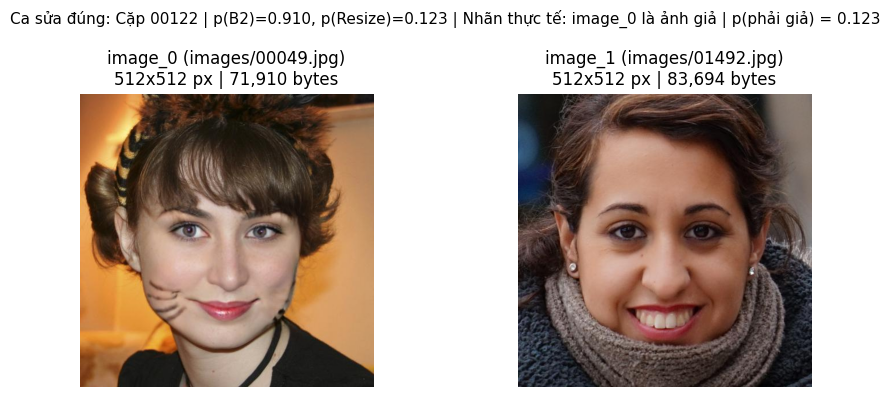


Hiển thị Ca làm sai: Cặp 00269 | p(B2)=0.566, p(Resize)=0.040...


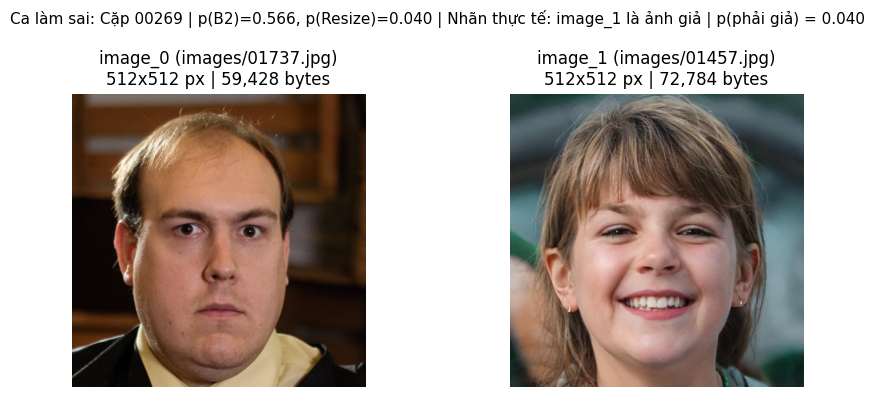

In [4]:
aligned_std = aligned_predictions(oof_b2, dev_frame)
aligned_aug = aligned_predictions(oof_b2_resize, dev_frame)

y_true = dev_frame['fake_position'].to_numpy()
p_std = aligned_std['p'].to_numpy()
p_aug = aligned_aug['p'].to_numpy()

pred_std = (p_std >= 0.5).astype(int)
pred_aug = (p_aug >= 0.5).astype(int)

helped_mask = (pred_std != y_true) & (pred_aug == y_true)
harmed_mask = (pred_std == y_true) & (pred_aug != y_true)

helped_ids = dev_frame.loc[helped_mask, 'pair_id'].tolist()
harmed_ids = dev_frame.loc[harmed_mask, 'pair_id'].tolist()

print(f"Phân tích chi tiết các ca thay đổi dự đoán:")
print(f"- Số ca Resize Augmentation giúp sửa đúng (từ sai thành đúng): {len(helped_ids)} cặp")
print(f"- Số ca Resize Augmentation làm hỏng (từ đúng thành sai):     {len(harmed_ids)} cặp")
print(f"- Thay đổi ròng:                                             {len(harmed_ids) - len(helped_ids):+d} lỗi")

if helped_ids:
    sample_h_id = sorted(helped_ids)[0]
    idx_h = dev_frame.index[dev_frame.pair_id == sample_h_id].item()
    row_h = dev_frame.iloc[idx_h]
    cap_h = f"Ca sửa đúng: Cặp {sample_h_id} | p(B2)={p_std[idx_h]:.3f}, p(Resize)={p_aug[idx_h]:.3f}"
    print(f"\nHiển thị {cap_h}...")
    show_pair_images(row_h, data_root, title=cap_h, p_pred=p_aug[idx_h])

if harmed_ids:
    sample_m_id = sorted(harmed_ids)[0]
    idx_m = dev_frame.index[dev_frame.pair_id == sample_m_id].item()
    row_m = dev_frame.iloc[idx_m]
    cap_m = f"Ca làm sai: Cặp {sample_m_id} | p(B2)={p_std[idx_m]:.3f}, p(Resize)={p_aug[idx_m]:.3f}"
    print(f"\nHiển thị {cap_m}...")
    show_pair_images(row_m, data_root, title=cap_m, p_pred=p_aug[idx_m])

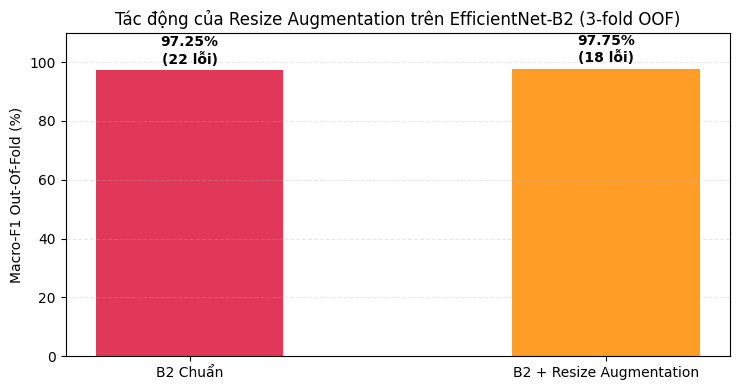

In [5]:
models_compared = ['B2 Chuẩn', 'B2 + Resize Augmentation']
f1_vals = [sc_b2['macro_f1'] * 100.0, sc_b2_resize['macro_f1'] * 100.0]
err_vals = [sc_b2['errors'], sc_b2_resize['errors']]

plt.figure(figsize=(7.5, 4.0))
bars = plt.bar(models_compared, f1_vals, color=['crimson', 'darkorange'], width=0.45, alpha=0.85)
plt.ylabel("Macro-F1 Out-Of-Fold (%)")
plt.title(f"Tác động của Resize Augmentation trên EfficientNet-B2 ({'Smoke' if KMD_SMOKE else '3-fold OOF'})")
plt.ylim(0, max(f1_vals) + 12)

for bar, f1_v, err_v in zip(bars, f1_vals, err_vals):
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, h + 1.2, f"{f1_v:.2f}%\n({err_v} lỗi)",
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Điều đã kiểm tra và câu hỏi còn lại

Nhãn ảnh thật/giả không tự đổi khi resize, nhưng dấu hiệu giúp mô hình nhận ra nhãn có thể đổi. Phép thử này đo khả năng dự đoán trên validation gốc sau khi thêm augmentation vào train. Muốn kết luận về độ bền trước ảnh test bị resize hoặc JPEG, cần một phép đánh giá biến đổi test riêng.

Xác suất 20% và hệ số 0,9-1,0 là lựa chọn can thiệp nhẹ trong preset, chưa phải giá trị tốt nhất. Ảnh minh họa dùng cố định 0,9 để nhìn rõ thao tác; nó không đại diện mọi lượt lấy mẫu ngẫu nhiên.

## 4. Tổng kết chuỗi phụ lục chuyên đề

Bốn phụ lục từ A đến D đã hoàn thiện các câu hỏi chuyên sâu mở rộng từ mạch bài chính:
- [Phụ lục A](extension_a_representations.ipynb): Trả lời bốn câu hỏi về biểu diễn đầu vào, tinh chỉnh từng phần, cơ chế gộp logit và bản đồ phần dư trên CNN.
- [Phụ lục B](extension_b_objectives_and_repair.ipynb): Khảo sát các biến thể hàm mục tiêu huấn luyện và phép đối chứng có kiểm soát cho kỹ thuật ghép cặp lại (re-pairing).
- [Phụ lục C](extension_c_data_scaling.ipynb): Đo lường sự thay đổi hiệu năng theo quy mô dữ liệu dưới ngân sách 391 cập nhật cố định.
- **Phụ lục D:** Đánh giá thận trọng vai trò của tăng cường dữ liệu co dãn ngẫu nhiên trong bài toán phát hiện ảnh giả mạo. Đối chứng giữ EfficientNet-B2 288px, không theo mô hình đơn hay blend của mạch chính.

Nếu muốn đưa các phụ lục vào bảng đối chiếu private, hoàn tất chúng trước bước khóa danh sách ở [Bài 07](07_private_and_submission.ipynb). Quy tắc chọn mô hình ở [Bài 05](05_backbone_and_selection.ipynb) và thử blend ở [Bài 06](06_errors_and_blend.ipynb) vẫn dùng nhóm ứng viên đã định sẵn. Kết quả A-D giúp đề xuất thí nghiệm tiếp theo, không tự thay đổi quy tắc của lượt chạy này.
